# BEE 4750 Lab 2: Monte Carlo

**Name**: Pranati Patnam

**ID**:pp444

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [141]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()
Pkg.add("Extremes")

  Activating project at `c:\Users\Pranati\OneDrive - Cornell University\Documents\BEE4750-GitHub\lab-2-PranatiP`
    Updating registry at `C:\Users\Pranati\.julia\registries\General.toml`
   Resolving package versions...
   Installed IntelOpenMP_jll ────────── v2025.2.0+0
   Installed EnumX ──────────────────── v1.0.5
   Installed ProgressMeter ──────────── v1.11.0
   Installed FFTW ───────────────────── v1.10.0
   Installed StaticArrays ───────────── v1.9.15
   Installed MambaLite ──────────────── v0.1.3
   Installed LazyGrids ──────────────── v0.5.0
   Installed Distances ──────────────── v0.10.12
   Installed ADTypes ────────────────── v1.18.0
   Installed NLSolversBase ──────────── v7.10.0
   Installed FiniteDiff ─────────────── v2.28.1
   Installed Loess ──────────────────── v0.6.4
   Installed Gadfly ─────────────────── v1.4.1
   Installed CommonSubexpressions ───── v0.3.1
   Installed oneTBB_jll ─────────────── v2022.0.0+0
   Installed Compat ─────────────────── v4.18.1
   Insta

In [142]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting
using Extremes
using DataFrames # Useful for handling data in a tabular format
using Distributions # Provides GEV distribution object (though Extremes.jl handles estimation)
using Gadfly # Or another plotting library like Plots.jl for visualizations

[ Info: Precompiling Extremes [fe3fe864-1b39-11e9-20b8-1f96fa57382d] (cache misses: wrong dep version loaded (2))


LoadError: ArgumentError: Package DataFrames not found in current path.
- Run `import Pkg; Pkg.add("DataFrames")` to install the DataFrames package.

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [ ]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [132]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 4
 3
 2
 ⋮
 2
 3
 3
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

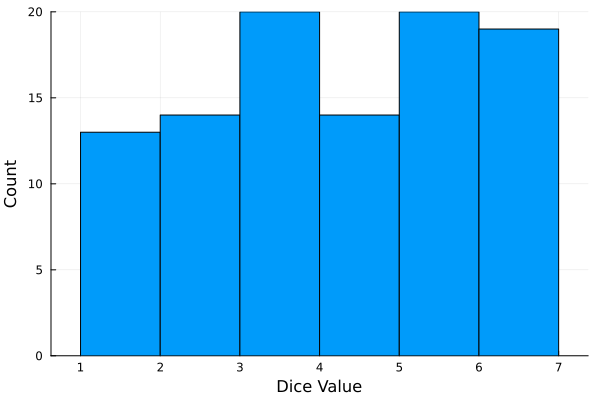

In [133]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

In [223]:
L  = 200_000.0   
k  = 0.8            
h0 = 3.0         

function damage(h)
    if h <= 0 #indicator
        return 0.0
    else
        numerator = L
        expo = -k * (h - h0)
        denominator = 1 + exp(expo)
        return numerator / denominator
    end
end 



damage (generic function with 3 methods)

In [ ]:
dist1 = LogNormal(1.2, 0.3) #lognorm
dist2 = GeneralizedExtremeValue(3.0, 0.9, -0.15) #GEV

function MC(dist; N=50000)
    hs = rand(dist, N)
    ds = damage.(hs)

    meanDam = mean(ds)
    se = std(ds) / sqrt(N)   
    q99 = quantile(ds, 0.99)

    return meanDam, se, q99, ds
end

MC (generic function with 1 method)

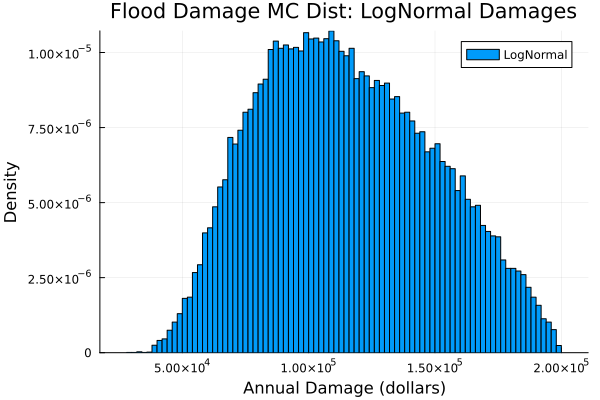

In [238]:
histogram(ds1, bins=100, label = "LogNormal", normalize=true)
xlabel!("Annual Damage (dollars)")
ylabel!("Density")
title!("Flood Damage MC Dist: LogNormal Damages")

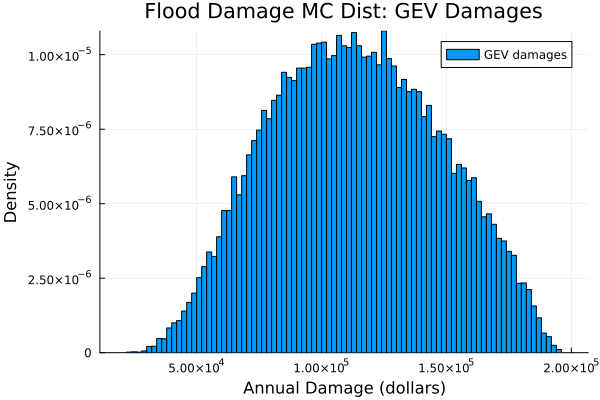

In [239]:
histogram(ds2, bins=100, label="GEV damages", normalize=true)
xlabel!("Annual Damage (dollars)")
ylabel!("Density")
title!("Flood Damage MC Dist: GEV Damages")

Question 1:

In [227]:
mean1, se1, q99_1, ds1 = MC(dist1)
mean2, se2, q99_2, ds2 = MC(dist2)

std1 = std(ds1)
std2 = std(ds2)

println("LogNormal dist:")
println("expected damage = \$$(round(mean1, digits=2))")
println("standard error = \$$(round(se1, digits=2))")
println("99% quantile = \$$(round(q99_1, digits=2))")
println("standard deviation = \$$(round(std1, digits=2))")

println()
println("GEV dist:")
println("exp damage = \$$(round(mean2, digits=2))")
println("standard error = \$$(round(se2, digits=2))")
println("99% quantile = \$$(round(q99_2, digits=2))")
println("standard deviation = \$$(round(std2, digits=2))")

LogNormal dist:
expected damage = $115179.75
standard error = $153.34
99% quantile = $190049.21
standard deviation = $34287.55

GEV dist:
exp damage = $113419.6
standard error = $150.08
99% quantile = $183575.67
standard deviation = $33558.12


Question 2: 
I ran a short pilot w/ 50000 samples to estimate the sample std dev of the damage for each distribution. If we want the standard error of the sample mean to be less, then from the slides: SE = sd/sqrt(N), and N = (sd/se)^2. Using the pilot sd gives an N ≈ 1,100–1,200 to reach SE ≈ $1,000. To be conservative and to get a more precise 99% quantile estimate, I picked N = 50000 where the actual SEs were ~$150 which is small compared to the mean (~0.1% relative SE).

for logNormal: std = 34312
N >= (34312/1000)^2 = 34.3^2 = 1177

for GEV: std = 33506
N >= (33506/1000)^2 = 33.5^2 = 1123

So roughly 1200 should be enough to be within +- 1000SE

Question 3: 
The means are pretty similar (115177 for LN vs 113287 for GEV). That makes sense because the depth histograms show both distributions having similar mass. the 99% quantiles due differ a little bit more than the means do (189901 for LN vs 183186 for GEV) -- LN has heavier right tail compared to GEV dist, so this makes sense why the upper quantiles would be higher. I'd say both distributions kind of "compress" near the upper bound of 200k, but definitely more so with the lognormal distribution

Question 4:

To decide which is better, I would compare tail behaviors a little better (QQ plots from 4850!), maybe include more physical constraints like other climate variables for input data (using observational data too). I could even look at monte carlo error vs model error, or run the monte carlo with different seeds to better assess the two models and their differences.

Question 5:

In [234]:
Random.seed!(7)

TaskLocalRNG()

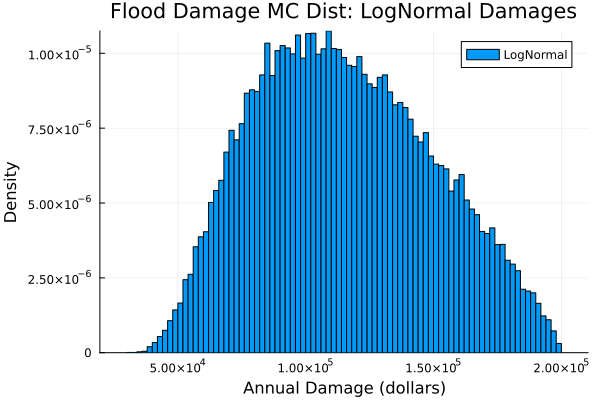

In [240]:
mean1, se1, q99_1, ds1 = MC(dist1)
mean2, se2, q99_2, ds2 = MC(dist2)

std1 = std(ds1)
std2 = std(ds2)


histogram(ds1, bins=100, label = "LogNormal", normalize=true)
xlabel!("Annual Damage (dollars)")
ylabel!("Density")
title!("Flood Damage MC Dist: LogNormal Damages")


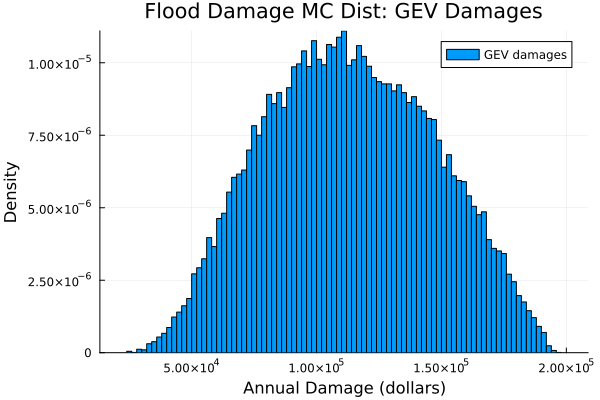

In [241]:
histogram(ds2, bins=100, label="GEV damages", normalize=true)
xlabel!("Annual Damage (dollars)")
ylabel!("Density")
title!("Flood Damage MC Dist: GEV Damages")

In [237]:
println("LogNormal dist:")
println("expected damage = \$$(round(mean1, digits=2))")
println("standard error = \$$(round(se1, digits=2))")
println("99% quantile = \$$(round(q99_1, digits=2))")
println("standard deviation = \$$(round(std1, digits=2))")

println()
println("GEV dist:")
println("exp damage = \$$(round(mean2, digits=2))")
println("standard error = \$$(round(se2, digits=2))")
println("99% quantile = \$$(round(q99_2, digits=2))")
println("standard deviation = \$$(round(std2, digits=2))")

LogNormal dist:
expected damage = $115221.13
standard error = $152.88
99% quantile = $189704.7
standard deviation = $34185.07

GEV dist:
exp damage = $113641.36
standard error = $150.64
99% quantile = $183367.44
standard deviation = $33683.15


With a random seed of 7 as the parameter instead of 1, the upper quantiles for the GEV dist are very very similar, as well as the mean. The means are similar for the logNormal dist as well, but the 99% quantile is a lot lower with this new seed. The random seed variability is small for the mean but perhaps a tiny bit more drastic for the quantiles; however this difference is not notable at all. This makes sense, since the tails would naturally be more variable.

## References

Put any consulted sources here, including classmates you worked with/who
helped you.

Emma P. and Adrian C-Y.